# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [1]:
from acceptor_TI import Problem

data_path = "../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
hopping_dict = problem.cell_parser.eigenvalues.nn_hopping.value
hopping_dict["t_ss_sigma"] = -1.4
hopping_dict["t_sp_sigma"] = 1
hopping_dict["t_pp_sigma"] = 1
hopping_dict["t_pp_pi"] = -0.5

In [3]:
location = "bulk"
problem.setup(
    N_r = 10,            # size of lattice in real space
    N_k = 300,           # reciprocal space discretization
    location = location  # location of where to calculate eigenvalues
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


## Clebsch-Gordan Coefficients

In [4]:
tb = problem.hamiltonian[location]["tight_binding"]

tb.CG_coefficients

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,-1;0.5,-0.5>': 1.00000000000000,
 '|1,-1;0.5,0.5>': 0.333333333333333*sqrt(3),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6),
 '|1,1;0.5,-0.5>': 0.333333333333333*sqrt(3),
 '|1,1;0.5,0.5>': 1.00000000000000}

In [5]:
tb.sublattice_data_dict["A"].keys()
sublattice = list(tb.sublattice_data_dict["A"].keys())[0]

## Coupled Angular Momentum States

In [6]:
if location == "bulk":
    idx = tb.sublattice_data_dict["A"]["neighbour_idxs"][0]
    tb.sublattice_data_dict["A"]['coupled_states_dict'][idx]
elif location == "edge":
    idx = tb.sublattice_data_dict["A"][sublattice]["neighbour_idxs"][0]
    tb.sublattice_data_dict["A"][sublattice]['hopping_dict'][idx]

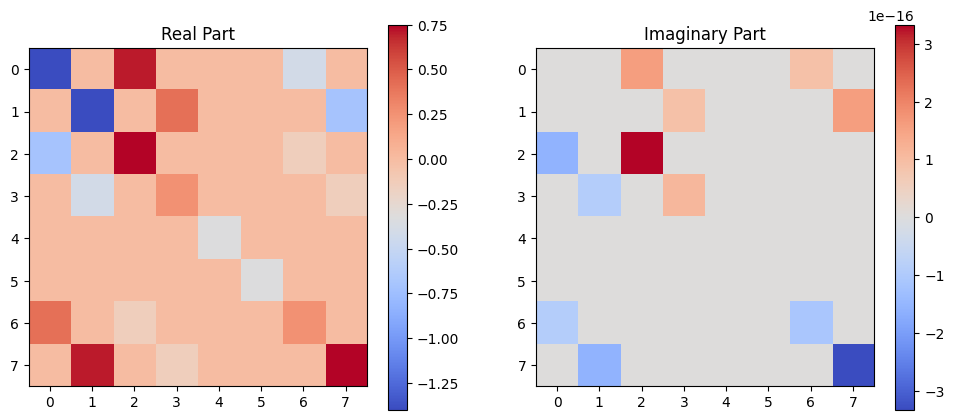

In [7]:
if location == "bulk":
    tb._visualise_matrix(tb.sublattice_data_dict["A"]['hopping_dict'][idx])
elif location == "edge":
    tb._visualise_matrix(tb.sublattice_data_dict["A"][sublattice]['hopping_dict'][idx])

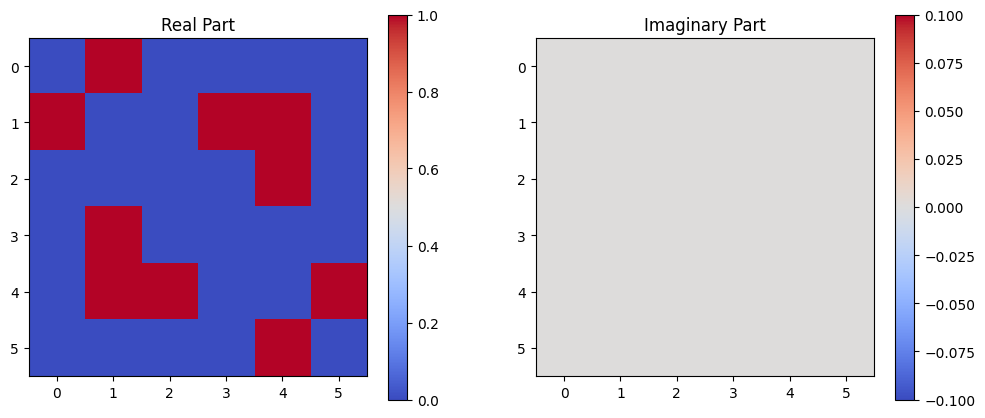

In [8]:
tb._visualise_matrix(tb.sublattice_connectivity)

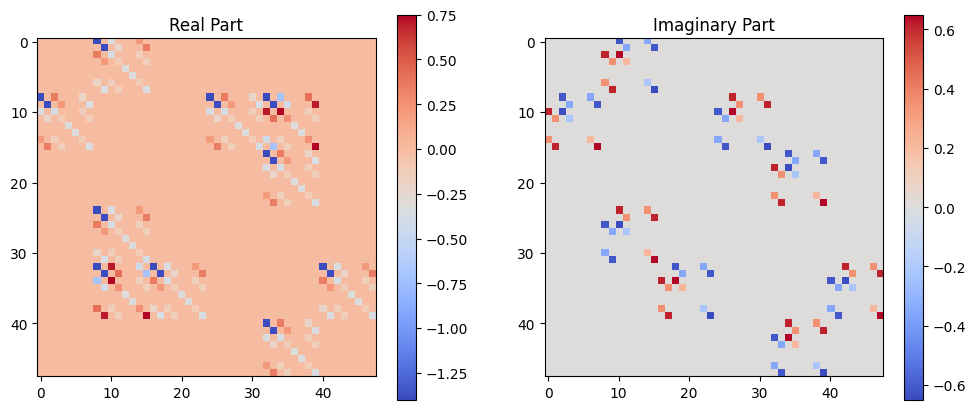

In [9]:
tb._visualise_matrix(tb.H)

In [10]:
problem.run(
    acceptor=False,
    H_type="real_space"
)

Calculating 'Bulk' eigenvalues...
'Bulk' Eigenvalues - Done.


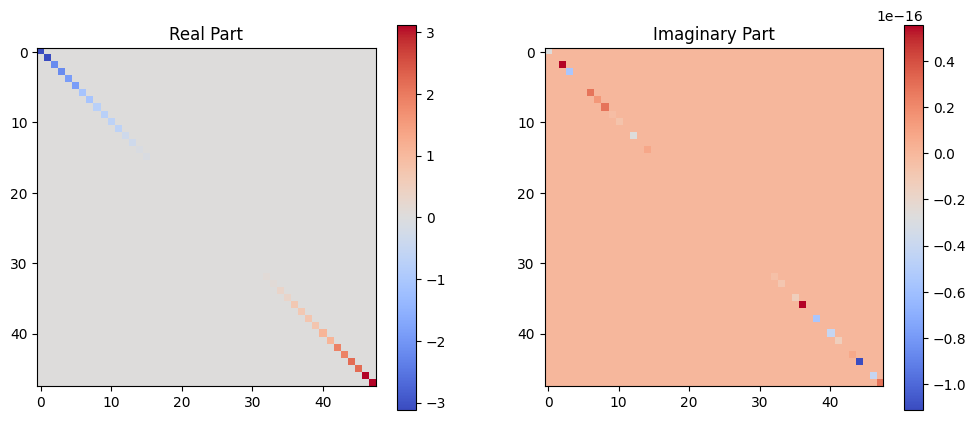

In [11]:
tb._visualise_matrix(tb.H_diag)

In [12]:
tb.E

array([-3.11824370e+00, -3.11824370e+00, -2.18295306e+00, -2.18295306e+00,
       -1.89278737e+00, -1.89278737e+00, -1.07391269e+00, -1.07391269e+00,
       -7.51162860e-01, -7.51162860e-01, -6.66666667e-01, -6.66666667e-01,
       -3.33333333e-01, -3.33333333e-01, -1.05328178e-01, -1.05328178e-01,
       -2.05802435e-15, -5.73135381e-16, -5.52074441e-17, -5.20717095e-17,
       -4.59176468e-17, -3.17440916e-17, -1.47090174e-17, -1.25903227e-17,
       -4.78528624e-18, -6.32876762e-19,  4.73634180e-19,  4.59393002e-18,
        1.21938857e-17,  1.33967860e-17,  7.15326279e-17,  2.01101243e-15,
        1.05328178e-01,  1.05328178e-01,  3.33333333e-01,  3.33333333e-01,
        6.66666667e-01,  6.66666667e-01,  7.51162860e-01,  7.51162860e-01,
        1.07391269e+00,  1.07391269e+00,  1.89278737e+00,  1.89278737e+00,
        2.18295306e+00,  2.18295306e+00,  3.11824370e+00,  3.11824370e+00])